In [1]:
import pandas as pd
import numpy as np
import optuna

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

from xgboost import XGBClassifier

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../data/raw/creditcard.csv")

X = df.drop("Class", axis=1)
y = df["Class"]

In [3]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    stratify=y,
    random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=42
)

In [4]:
scaler = StandardScaler()

scaler.fit(X_train[["Time", "Amount"]])

X_train = X_train.copy()
X_val = X_val.copy()
X_test = X_test.copy()

X_train[["Time", "Amount"]] = scaler.transform(
    X_train[["Time", "Amount"]]
)

X_val[["Time", "Amount"]] = scaler.transform(
    X_val[["Time", "Amount"]]
)

X_test[["Time", "Amount"]] = scaler.transform(
    X_test[["Time", "Amount"]]
)

In [5]:
negative = (y_train == 0).sum()
positive = (y_train == 1).sum()

scale_pos_weight = negative / positive

print(f"Negative samples: {negative}")
print(f"Positive samples: {positive}")
print(f"Scale pos weight: {scale_pos_weight:.2f}")

Negative samples: 199020
Positive samples: 344
Scale pos weight: 578.55


In [6]:
def objective(trial):
    
    params = {
        "n_estimators": trial.suggest_int(
            "n_estimators",
            200,
            600
        ),

        "max_depth": trial.suggest_int(
            "max_depth",
            3,
            10
        ),

        "learning_rate": trial.suggest_float(
            "learning_rate",
            0.01,
            0.2,
            log=True
        ),

        "min_child_weight": trial.suggest_int(
            "min_child_weight",
            1,
            10
        ),

        "subsample": trial.suggest_float(
            "subsample",
            0.6,
            1.0
        ),

        "colsample_bytree": trial.suggest_float(
            "colsample_bytree",
            0.6,
            1.0
        ),

        "gamma": trial.suggest_float(
            "gamma",
            0,
            5
        ),

        "scale_pos_weight": scale_pos_weight,

        "objective": "binary:logistic",

        "eval_metric": "aucpr",

        "random_state": 42,

        "n_jobs": -1
    }

    model = XGBClassifier(**params)

    model.fit(
        X_train,
        y_train
    )

    probabilities = model.predict_proba(X_val)[:, 1]

    pr_auc = average_precision_score(
        y_val,
        probabilities
    )

    return pr_auc

In [7]:
study = optuna.create_study(
    direction="maximize"
)

[I 2026-08-28 18:33:39,589] A new study created in memory with name: no-name-3896cf24-b9ff-490d-b0b2-a828c46a7a4b


In [8]:
study.optimize(
    objective,
    n_trials=20
)

[I 2026-08-28 18:33:45,311] Trial 0 finished with value: 0.8325213247832692 and parameters: {'n_estimators': 270, 'max_depth': 8, 'learning_rate': 0.08933326800675928, 'min_child_weight': 10, 'subsample': 0.7021785902071653, 'colsample_bytree': 0.6087407217809294, 'gamma': 0.7725869362020538}. Best is trial 0 with value: 0.8325213247832692.
[I 2026-08-28 18:33:47,008] Trial 1 finished with value: 0.8271927925994566 and parameters: {'n_estimators': 548, 'max_depth': 4, 'learning_rate': 0.14742615901304257, 'min_child_weight': 5, 'subsample': 0.7888017327273511, 'colsample_bytree': 0.861245766086801, 'gamma': 4.8843091292001}. Best is trial 0 with value: 0.8325213247832692.
[I 2026-08-28 18:33:48,065] Trial 2 finished with value: 0.8036601573354811 and parameters: {'n_estimators': 261, 'max_depth': 3, 'learning_rate': 0.11188503117567705, 'min_child_weight': 2, 'subsample': 0.7437556089681808, 'colsample_bytree': 0.805156966796932, 'gamma': 0.3254329940010736}. Best is trial 0 with value

In [9]:
print("Best PR-AUC:")
print(study.best_value)

Best PR-AUC:
0.8393546296554086


In [10]:
print("Best Parameters:")

for parameter, value in study.best_params.items():
    print(f"{parameter}: {value}")

Best Parameters:
n_estimators: 320
max_depth: 7
learning_rate: 0.07178615670002696
min_child_weight: 8
subsample: 0.8564225356041633
colsample_bytree: 0.9938764977176296
gamma: 2.426447357015321


In [11]:
best_params = study.best_params.copy()

best_params.update({
    "scale_pos_weight": scale_pos_weight,
    "objective": "binary:logistic",
    "eval_metric": "aucpr",
    "random_state": 42,
    "n_jobs": -1
})

In [12]:
best_xgb = XGBClassifier(
    **best_params
)

In [13]:
best_xgb.fit(
    X_train,
    y_train
)

,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.9938764977176296
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'aucpr'
,feature_types feature_types: typing.Sequence[str] | None.. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [14]:
best_val_proba = best_xgb.predict_proba(
    X_val
)[:, 1]

In [15]:
best_val_pred = (
    best_val_proba >= 0.5
).astype(int)

In [16]:
best_precision = precision_score(
    y_val,
    best_val_pred,
    zero_division=0
)

best_recall = recall_score(
    y_val,
    best_val_pred,
    zero_division=0
)

best_f1 = f1_score(
    y_val,
    best_val_pred,
    zero_division=0
)

best_roc_auc = roc_auc_score(
    y_val,
    best_val_proba
)

best_pr_auc = average_precision_score(
    y_val,
    best_val_proba
)

In [17]:
print("========== OPTIMIZED XGBOOST ==========")

print(f"Precision: {best_precision:.4f}")
print(f"Recall:    {best_recall:.4f}")
print(f"F1 Score:  {best_f1:.4f}")
print(f"ROC-AUC:   {best_roc_auc:.4f}")
print(f"PR-AUC:    {best_pr_auc:.4f}")

========== OPTIMIZED XGBOOST ==========
Precision: 0.8082
Recall:    0.7973
F1 Score:  0.8027
ROC-AUC:   0.9808
PR-AUC:    0.8394


In [23]:
from xgboost import XGBClassifier

# Calculate class imbalance
negative = (y_train == 0).sum()
positive = (y_train == 1).sum()

scale_pos_weight = negative / positive

print(f"Scale pos weight: {scale_pos_weight:.2f}")

Scale pos weight: 578.55


In [24]:
xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    objective="binary:logistic",
    eval_metric="aucpr",
    random_state=42,
    n_jobs=-1
)

In [25]:
xgb_model.fit(
    X_train,
    y_train
)

,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.8
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'aucpr'
,feature_types feature_types: typing.Sequence[str] | None.. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [26]:
original_proba = xgb_model.predict_proba(X_val)[:, 1]

original_pred = (
    original_proba >= 0.5
).astype(int)

In [27]:
original_precision = precision_score(
    y_val,
    original_pred,
    zero_division=0
)

original_recall = recall_score(
    y_val,
    original_pred,
    zero_division=0
)

original_f1 = f1_score(
    y_val,
    original_pred,
    zero_division=0
)

original_roc_auc = roc_auc_score(
    y_val,
    original_proba
)

original_pr_auc = average_precision_score(
    y_val,
    original_proba
)

In [28]:
comparison = pd.DataFrame({
    "Original XGBoost": {
        "Precision": original_precision,
        "Recall": original_recall,
        "F1": original_f1,
        "ROC-AUC": original_roc_auc,
        "PR-AUC": original_pr_auc
    },

    "Optimized XGBoost": {
        "Precision": best_precision,
        "Recall": best_recall,
        "F1": best_f1,
        "ROC-AUC": best_roc_auc,
        "PR-AUC": best_pr_auc
    }
}).T

comparison

,Precision,Recall,F1,ROC-AUC,PR-AUC
Original XGBoost,0.890625,0.770270,0.826087,0.983317,0.834440
Optimized XGBoost,0.808219,0.797297,0.802721,0.980777,0.839355


In [33]:
thresholds = np.arange(
    0.01,
    1.00,
    0.01
)

threshold_results = []

for threshold in thresholds:

    predictions = (
        best_val_proba >= threshold
    ).astype(int)

    threshold_results.append({
        "threshold": threshold,

        "precision": precision_score(
            y_val,
            predictions,
            zero_division=0
        ),

        "recall": recall_score(
            y_val,
            predictions,
            zero_division=0
        ),

        "f1": f1_score(
            y_val,
            predictions,
            zero_division=0
        )
    })

threshold_results = pd.DataFrame(
    threshold_results
)

In [34]:
best_threshold_row = threshold_results.loc[
    threshold_results["f1"].idxmax()
]

best_threshold_row

threshold    0.830000
precision    0.935484
recall       0.783784
f1           0.852941
Name: 82, dtype: float64

In [35]:
best_threshold = best_threshold_row["threshold"]

print(
    f"Best F1 threshold: {best_threshold:.2f}"
)

Best F1 threshold: 0.83


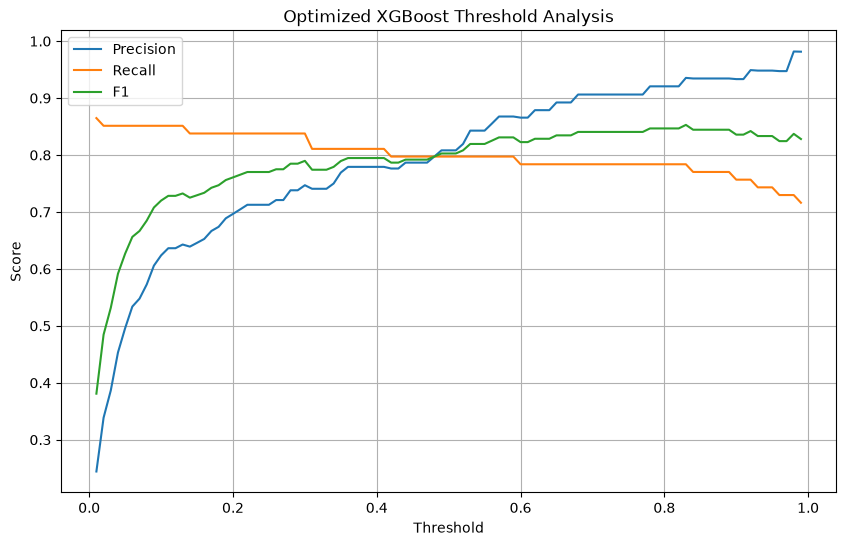

In [36]:
plt.figure(figsize=(10, 6))

plt.plot(
    threshold_results["threshold"],
    threshold_results["precision"],
    label="Precision"
)

plt.plot(
    threshold_results["threshold"],
    threshold_results["recall"],
    label="Recall"
)

plt.plot(
    threshold_results["threshold"],
    threshold_results["f1"],
    label="F1"
)

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Optimized XGBoost Threshold Analysis")

plt.legend()
plt.grid(True)

plt.show()

In [38]:
study_results = study.trials_dataframe()

study_results.to_csv(
    "../results/optuna_trials.csv",
    index=False
)

In [39]:
import json

with open(
    "../results/best_xgb_params.json",
    "w"
) as f:
    json.dump(
        best_params,
        f,
        indent=4
    )

In [40]:
print(best_threshold)
print(X_test.shape)
print(y_test.shape)

0.8300000000000001
(42722, 30)
(42722,)


In [41]:
test_proba = best_xgb.predict_proba(
    X_test
)[:, 1]

In [42]:
test_pred = (
    test_proba >= best_threshold
).astype(int)

In [43]:
test_precision = precision_score(
    y_test,
    test_pred,
    zero_division=0
)

test_recall = recall_score(
    y_test,
    test_pred,
    zero_division=0
)

test_f1 = f1_score(
    y_test,
    test_pred,
    zero_division=0
)

test_roc_auc = roc_auc_score(
    y_test,
    test_proba
)

test_pr_auc = average_precision_score(
    y_test,
    test_proba
)

In [44]:
print("====================================")
print("       FINAL TEST PERFORMANCE")
print("====================================")

print(f"Threshold : {best_threshold:.2f}")
print(f"Precision : {test_precision:.4f}")
print(f"Recall    : {test_recall:.4f}")
print(f"F1 Score  : {test_f1:.4f}")
print(f"ROC-AUC   : {test_roc_auc:.4f}")
print(f"PR-AUC    : {test_pr_auc:.4f}")

       FINAL TEST PERFORMANCE
Threshold : 0.83
Precision : 0.8806
Recall    : 0.7973
F1 Score  : 0.8369
ROC-AUC   : 0.9681
PR-AUC    : 0.8399


In [45]:
print(
    classification_report(
        y_test,
        test_pred,
        target_names=[
            "Legitimate",
            "Fraud"
        ],
        zero_division=0
    )
)

              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     42648
       Fraud       0.88      0.80      0.84        74

    accuracy                           1.00     42722
   macro avg       0.94      0.90      0.92     42722
weighted avg       1.00      1.00      1.00     42722



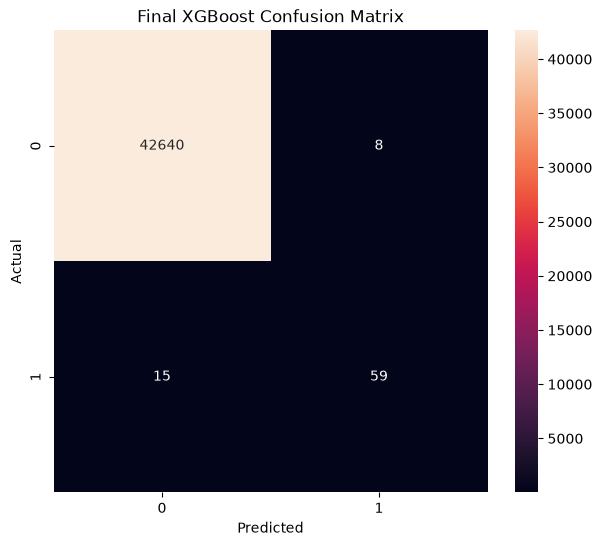

In [46]:
final_cm = confusion_matrix(
    y_test,
    test_pred
)

plt.figure(figsize=(7, 6))

sns.heatmap(
    final_cm,
    annot=True,
    fmt="d"
)

plt.title("Final XGBoost Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [47]:
tn, fp, fn, tp = final_cm.ravel()

print("True Negatives :", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives :", tp)

True Negatives : 42640
False Positives: 8
False Negatives: 15
True Positives : 59


In [48]:
false_positive_rate = fp / (fp + tn)

print(
    f"False Positive Rate: {false_positive_rate:.6f}"
)

False Positive Rate: 0.000188


In [49]:
false_negative_rate = fn / (fn + tp)

print(
    f"False Negative Rate: {false_negative_rate:.6f}"
)


False Negative Rate: 0.202703


In [50]:
from sklearn.metrics import roc_curve


In [51]:
fpr, tpr, thresholds = roc_curve(
    y_test,
    test_proba
)

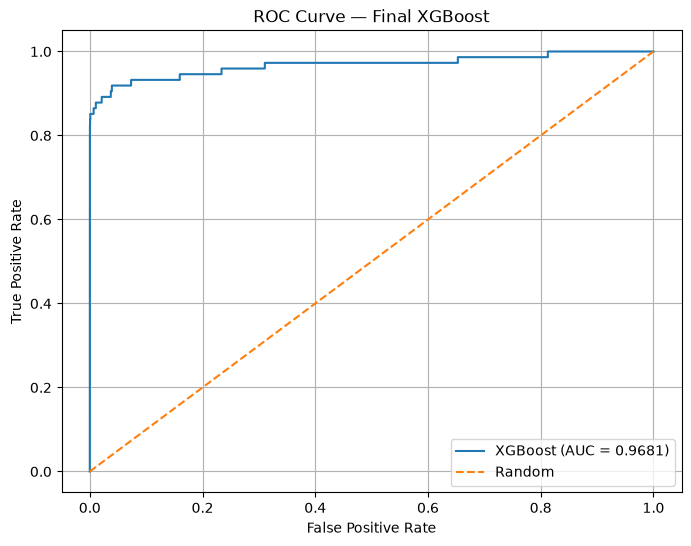

In [52]:
plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"XGBoost (AUC = {test_roc_auc:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Final XGBoost")
plt.legend()
plt.grid(True)

plt.show()

In [53]:
from sklearn.metrics import precision_recall_curve

In [54]:
precision_values, recall_values, pr_thresholds = (
    precision_recall_curve(
        y_test,
        test_proba
    )
)

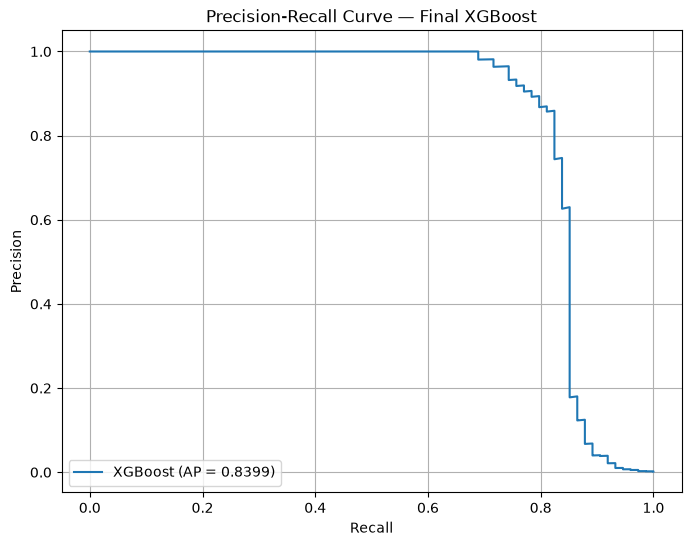

In [55]:
plt.figure(figsize=(8, 6))

plt.plot(
    recall_values,
    precision_values,
    label=f"XGBoost (AP = {test_pr_auc:.4f})"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve — Final XGBoost")
plt.legend()
plt.grid(True)

plt.show()

In [56]:
final_comparison = pd.DataFrame({
    "Validation": {
        "Precision": best_precision,
        "Recall": best_recall,
        "F1": best_f1,
        "ROC-AUC": best_roc_auc,
        "PR-AUC": best_pr_auc
    },

    "Test": {
        "Precision": test_precision,
        "Recall": test_recall,
        "F1": test_f1,
        "ROC-AUC": test_roc_auc,
        "PR-AUC": test_pr_auc
    }
}).T

final_comparison

,Precision,Recall,F1,ROC-AUC,PR-AUC
Validation,0.808219,0.797297,0.802721,0.980777,0.839355
Test,0.880597,0.797297,0.836879,0.968103,0.839895


In [57]:
final_metrics = {
    "threshold": float(best_threshold),
    "precision": float(test_precision),
    "recall": float(test_recall),
    "f1": float(test_f1),
    "roc_auc": float(test_roc_auc),
    "pr_auc": float(test_pr_auc),
    "true_negatives": int(tn),
    "false_positives": int(fp),
    "false_negatives": int(fn),
    "true_positives": int(tp)
}

In [58]:
import json

with open(
    "../results/final_metrics.json",
    "w"
) as f:
    json.dump(
        final_metrics,
        f,
        indent=4
    )

In [59]:
with open(
    "../results/decision_threshold.txt",
    "w"
) as f:
    f.write(str(best_threshold))

In [60]:
import joblib

In [61]:
joblib.dump(
    best_xgb,
    "../results/fraud_detection_xgb.pkl"
)

['../results/fraud_detection_xgb.pkl']

In [62]:
joblib.dump(
    scaler,
    "../results/scaler.pkl"
)

['../results/scaler.pkl']

In [63]:
summary = {
    "model": "XGBoost",
    "optimization": "Optuna",
    "optimization_metric": "PR-AUC",
    "threshold_selection": "Validation set",
    "test_set_used_for_tuning": False,
    "threshold": float(best_threshold),
    "precision": float(test_precision),
    "recall": float(test_recall),
    "f1": float(test_f1),
    "roc_auc": float(test_roc_auc),
    "pr_auc": float(test_pr_auc)
}

summary

{'model': 'XGBoost',
 'optimization': 'Optuna',
 'optimization_metric': 'PR-AUC',
 'threshold_selection': 'Validation set',
 'test_set_used_for_tuning': False,
 'threshold': 0.8300000000000001,
 'precision': 0.8805970149253731,
 'recall': 0.7972972972972973,
 'f1': 0.8368794326241135,
 'roc_auc': 0.9681028101821574,
 'pr_auc': 0.8398953525475098}